# 3.2 · agent_traj — 저 물체는 어디로 가는가

지목한 물체 하나의 3초 뒤를 예측합니다. 지평선 안에 섹터를 벗어나면 그렇다고 명시적으로 답합니다.

이 노트북은 네 가지를 확인합니다 — **어떤 원시 데이터에서**, **어떤 코드를 거쳐**, **무엇이 입력으로 들어가고**, **빌드된 파일이 그 코드와 일치하는지**. GPU 는 필요 없습니다.

In [1]:
import os, sys, json, textwrap
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import pandas as pd

from datatools import paths

ITEMS = os.path.join(paths.COMMON_DIR, "instruct_items_tasks01_06.parquet")
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 80)
wrap = lambda s, i="   ": textwrap.fill(str(s), 94, initial_indent=i,
                                        subsequent_indent=i)
VARIANTS = ['agent_traj_azdeg', 'agent_traj_bbox']
print("variants:", VARIANTS)

variants: ['agent_traj_azdeg', 'agent_traj_bbox']


## 1. 어떤 원시 데이터에서 오는가

| 아카이브 | 주기 | 읽는 것 |
|---|---|---|
| `obstacle.offline` | 10 Hz | 대상의 현재와 미래 위치 |
| `egomotion` | 10 Hz | 월드 변환 |
| `radar` | 20 / 12.7 Hz | 시선속도 — 이 태스크의 핵심 근거 |
| `camera intrinsics` | 클립당 1 | bbox 형식 |

## 2. 어떤 코드를 거치는가

실행 순서입니다.

| 함수 | 하는 일 |
|---|---|
| `visible_at(boxes, t_s)` | 현재 물체들 |
| `movers[0]` | 가장 가까운 이동 물체를 대상으로 |
| `visible_at(boxes, t_s + h)` | 각 지평선에서 같은 track_id 를 추적 |
| `image_bbox(...)` | bbox 형식: 미래 시점의 박스 |
| `object_evidence` | CoT 용 반사점·시선속도 |

전부 `datatools/frame_objects.py` 와 `datatools/geometry.py` 에 있습니다.

In [2]:
import inspect
from datatools import frame_objects as F
for name in ['visible_at', 'movers[0]', 'visible_at', 'image_bbox', 'object_evidence']:
    fn = getattr(F, name, None)
    if fn is None:
        from datatools import geometry as G
        fn = getattr(G, name, None)
    if fn is None or not callable(fn):
        print(f'{name}: (모듈 함수 아님)'); continue
    doc = (inspect.getdoc(fn) or '').split(chr(10))[0]
    print(f'{name:34s} {doc[:80]}')

visible_at                         One row per track near `t_s`, inside the forward sector, nearest first.
movers[0]: (모듈 함수 아님)
visible_at                         One row per track near `t_s`, inside the forward sector, nearest first.
image_bbox                         Axis-aligned image box for a 3D box, or None if it is not visible.
object_evidence                    Per-box radar evidence, geometry included: how many returns, how many


## 3. 입력으로 무엇이 들어가는가

**비전 2장 · 레이더 20스캔 (2초, 10 Hz) · ego 20샘플**

입력 창은 태스크마다 다릅니다. 로더의 `WINDOWS` 표가 그것을 정하고, 레이더는 항상 20스캔이라 창의 길이가 바뀌면 샘플링 속도가 따라 바뀝니다 — 인코더 입력 모양은 변하지 않습니다.

In [3]:
from training.instruct_data import WINDOWS, INSTANT_TASKS, WINDOW_TASKS
for v in VARIANTS:
    for name in (v, v + "_cot"):
        if name in WINDOWS:
            secs, hz, frames = WINDOWS[name]
            print(f"{name:26s} 창 {secs}초 · 레이더 {hz} Hz × 20스캔 · 비전 {frames}장")
        elif name in INSTANT_TASKS:
            print(f"{name:26s} 순간 — 비전 1장 · 레이더 20스캔/1초 · ego 1")
        else:
            print(f"{name:26s} 클립 전체 — 비전 20장 · 레이더 20스캔/20초")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


agent_traj_azdeg           창 2초 · 레이더 10 Hz × 20스캔 · 비전 2장
agent_traj_azdeg_cot       창 2초 · 레이더 10 Hz × 20스캔 · 비전 2장
agent_traj_bbox            창 2초 · 레이더 10 Hz × 20스캔 · 비전 2장
agent_traj_bbox_cot        창 2초 · 레이더 10 Hz × 20스캔 · 비전 2장


## 4. 예제 10건 — 원시 입력째로

`notebooks/example_data/` 에 테스크마다 10건이 들어 있습니다. **parquet 도 원본 아카이브도 필요 없습니다.**

| 경로 | 내용 |
|---|---|
| `gen_data/<task>.jsonl` | LLM 학습에 쓰이는 아이템 그대로 — instruction, ego, 정답, 근거 |
| `raw/<task>/NN/frames/` | 그 아이템에 실제로 들어가는 프레임 |
| `raw/<task>/NN/radar.npz` | 그 창의 레이더 반사점 (패딩 제거) |

평문 변형과 CoT 변형은 같은 아이템입니다 — CoT 정답의 `answer` 필드가 평문 정답과 글자 그대로 같아서, 한 건이 둘을 모두 보여줍니다.

In [4]:
import glob
EX = os.path.abspath(os.path.join(os.getcwd(), "..", "example_data"))
examples = {}
for v in VARIANTS:
    path = os.path.join(EX, "gen_data", v + ".jsonl")
    examples[v] = [json.loads(l) for l in open(path)] if os.path.exists(path) else []
    print(f"{v:26s} {len(examples[v]):>2}건")
rows = [{"id": r["id"], "clip": r["clip_id"][:8], "프레임": r["n_frames"],
         "레이더 점": r["radar_points"], "정답 길이": len(r["target"]),
         "근거 길이": len(r["rationale"])}
        for v in VARIANTS for r in examples[v]]
pd.DataFrame(rows)

agent_traj_azdeg           10건
agent_traj_bbox            10건


,id,clip,프레임,레이더 점,정답 길이,근거 길이
0,agent_traj_azdeg/00,21177c72,2,6089,58,164
1,agent_traj_azdeg/01,6d2ce0dc,2,20367,49,222
2,agent_traj_azdeg/02,ee34f77a,2,2559,55,167
3,agent_traj_azdeg/03,16f01ed1,2,13767,50,158
4,agent_traj_azdeg/04,7fa9a91b,2,8334,29,156
5,agent_traj_azdeg/05,a74a7974,2,2324,58,106
6,agent_traj_azdeg/06,067be972,2,4414,29,220
7,agent_traj_azdeg/07,6f0ad652,2,13357,61,171
8,agent_traj_azdeg/08,cce4b7b9,2,4165,29,222
9,agent_traj_azdeg/09,aa4daacf,2,5736,60,179


한 건을 통째로 봅니다. instruction 이 출력 형식을 고르고, 근거가 그 형식의 답으로 이어집니다.

In [5]:
pool = examples[VARIANTS[0]]
# 예제는 전방 레이더가 있는 클립에서만 뽑았다. 데이터 전체로는 177,891 클립 중
# 17,130건(9.6%)이 전방 레이더가 없고, 그 조건에서는 아래 그림이 빈 채로 나온다.
r = next((x for x in pool if x["radar_points"]), pool[0])
if not r["radar_points"]:
    print("!! 이 예제는 전방 레이더가 없는 클립입니다 (반사점 0개)")
print("=" * 96)
print(f"{r['id']}   clip {r['clip_id'][:8]}   {r['sensors']}")
print(f"창: {r['window']}")
print()
print("instruction:"); print(wrap(r["instruction"].replace(chr(10), " | ")))
print("ego:");         print(wrap(r["ego"]))
print("answer (GT):"); print(wrap(r["target"]))
print("rationale:");   print(wrap(r["rationale"]))

agent_traj_azdeg/00   clip 21177c72   Sensors present: camera, ego motion, imaging long-range radar.
창: {'kind': 'window', 'seconds': 2, 'radar_hz': 10, 'video_frames': 2}

instruction:
   At frame 18. Track #577 is a bus at 8 m, azimuth -25 deg. Where will it be over the next 3
   seconds? Answer as range in metres and azimuth in degrees, or say 'leaves the forward
   sector' for a horizon it does not reach.
ego:
   Ego motion (binned, 2 s at 10 Hz, ending at t=17s): t0:s1a13y16 t1:s1a14y15 t2:s1a14y15
   t3:s1a14y16 t4:s1a13y16 t5:s1a13y15 t6:s1a14y15 t7:s1a13y16 t8:s1a13y16 t9:s1a13y16
   t10:s1a12y16 t11:s1a12y15 t12:s1a12y15 t13:s1a12y16 t14:s1a11y16 t15:s0a12y16 t16:s0a12y15
   t17:s0a13y16 t18:s0a13y16 t19:s0a13y15
answer (GT):
   +1s 7 m az -26 deg; +2s 7 m az -27 deg; +3s 7 m az -27 deg
rationale:
   #577 bus is at 8 m az -25 deg now, camera az -17 deg, radar 16 returns at 9 m, radial -0.6
   m/s, so it is closing: radial velocity times time is the change in range.


그 아이템에 실제로 들어가는 프레임과 레이더 반사점입니다. 레이더는 자차 기준 좌표(x 전방, y 좌)이고 색이 시선속도 — 정지 물체는 자차 속도의 음수로 모여 보입니다.

프레임 2장 · 반사점 6089개 · 채널 ['x', 'y', 'z', 'radial_velocity', 'doppler_residual', 'rcs', 'snr', 'range']


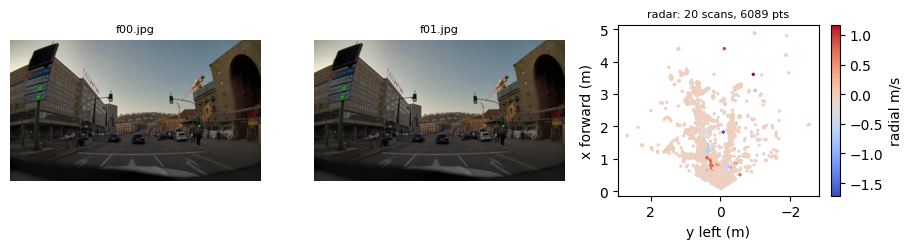

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

d = os.path.join(EX, r["raw"])
paths = sorted(glob.glob(os.path.join(d, "frames", "*.jpg")))
z = np.load(os.path.join(d, "radar.npz"))
pts, ch = z["points"].astype(np.float32), [str(c) for c in z["channels"]]
print(f"프레임 {len(paths)}장 · 반사점 {len(pts)}개 · 채널 {ch}")

fig, axes = plt.subplots(1, len(paths) + 1, figsize=(3.1 * (len(paths) + 1), 2.6))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p)); ax.set_title(os.path.basename(p), fontsize=8)
    ax.axis("off")
ax = axes[-1]
# 그림 안 글자는 ASCII 로 둔다. matplotlib 의 기본 폰트에 한글 글리프가 없어
# 라벨이 네모로 나오고, 폰트 등록을 요구하면 노트북이 기계를 가린다.
if len(pts):
    s = ax.scatter(pts[:, ch.index("y")], pts[:, ch.index("x")], s=2,
                   c=pts[:, ch.index("radial_velocity")], cmap="coolwarm")
    ax.set_title(f"radar: {r['radar_scans']} scans, {len(pts)} pts", fontsize=8)
    ax.invert_xaxis(); fig.colorbar(s, ax=ax, label="radial m/s")
else:
    ax.text(0.5, 0.5, "no returns", ha="center", va="center")
    ax.set_title("clip has no forward radar", fontsize=8)
ax.set_xlabel("y left (m)"); ax.set_ylabel("x forward (m)")
plt.tight_layout(); plt.show()

## 5. 빌드된 파일의 실제 아이템

여기서부터는 parquet 이 있는 기계에서만 돕니다. 위의 예제가 빌드 전체와 같은 규칙으로 만들어졌는지 확인하는 절입니다.

In [7]:
built = pd.read_parquet(ITEMS)
for v in VARIANTS:
    sub = built[built.task == v]
    if sub.empty:
        print(f"{v}: 파일에 없음"); continue
    r = sub.iloc[0]
    print("=" * 96)
    print(f"{v}   clip {r.clip_id[:8]}  frame {r.frame} (t={r.frame-1}s)  split {r.split}")
    print("Q:"); print(wrap(r.prompt))
    print("A:"); print(wrap(r.target))

agent_traj_azdeg   clip 1f47bf7f  frame 8 (t=7s)  split train
Q:
   Track #110 is a automobile at 64 m, azimuth -11 deg. Where will it be over the next 3
   seconds? Answer as range in metres and azimuth in degrees, or say 'leaves the forward
   sector' for a horizon it does not reach.
A:
   +1s 54 m az -12 deg; +2s 44 m az -13 deg; +3s 33 m az -18 deg
agent_traj_bbox   clip 1f47bf7f  frame 8 (t=7s)  split train
Q:
   Track #110 is a automobile at 64 m, azimuth -11 deg. Where will it be over the next 3
   seconds? Answer as an image bounding box [x1, y1, x2, y2] normalised to 0-1000, or say
   'leaves the forward sector' for a horizon it does not reach.
A:
   +1s [581, 483, 622, 511]; +2s [594, 488, 645, 525]; +3s [623, 480, 692, 529]


## 6. CoT — 근거가 답을 만드는가

`_cot` 변형은 `{"rationale": ..., "answer": ...}` 입니다. **근거를 따라가면 답이 나와야** 합니다. 나오지 않으면 그 사슬은 잘못된 것이고, 보상을 걸면 모델이 그 잘못된 사슬을 배웁니다.

In [8]:
for v in VARIANTS:
    name = v + "_cot"
    sub = built[built.task == name] if 'built' in dir() else None
    if sub is None or sub.empty:
        continue
    r = sub.iloc[0]
    d = json.loads(r.target)
    print("=" * 96); print(name)
    print("R:"); print(wrap(d["rationale"]))
    print("A:"); print(wrap(d["answer"]))

agent_traj_azdeg_cot
R:
   #110 automobile is at 64 m az -11 deg now, camera az -11 deg, no radar return, so its speed
   is not measured.
A:
   +1s 54 m az -12 deg; +2s 44 m az -13 deg; +3s 33 m az -18 deg
agent_traj_bbox_cot
R:
   #110 automobile is at 64 m az -11 deg now, camera az -11 deg, no radar return, so its speed
   is not measured.
A:
   +1s [581, 483, 622, 511]; +2s [594, 488, 645, 525]; +3s [623, 480, 692, 529]


## 7. 보상

평가 채점기에서 유도했습니다. 정답을 그대로 넣으면 1.0 이 나와야 하고, 내용을 망가뜨리면 떨어져야 합니다.

In [9]:
import re
from training.task_scorers import reward_for

def wreck(text):
    """형식은 두고 숫자만 2배로."""
    return re.sub(r"\d+(?:\.\d+)?",
                  lambda m: str(round(float(m.group()) * 2, 1)), text)

rows = []
for v in VARIANTS:
    for name in (v, v + "_cot"):
        fn = reward_for(name)
        if fn is None:
            continue
        sub = built[built.task == name] if 'built' in dir() else None
        if sub is None or sub.empty:
            continue
        t = sub.iloc[0].target
        rows.append({"task": name, "reward": fn.__name__,
                     "정답": round(fn(t, t), 3),
                     "숫자 2배": round(fn(wreck(t), t), 3)})
pd.DataFrame(rows)

,task,reward,정답,숫자 2배
0,agent_traj_azdeg,reward_trajectory,1.0,0.00
1,agent_traj_azdeg_cot,reward_with_rationale[agent_traj_azdeg],1.0,0.15
2,agent_traj_bbox,reward_trajectory,1.0,0.00
3,agent_traj_bbox_cot,reward_with_rationale[agent_traj_bbox],1.0,0.15


## 8. 데이터 양

`val` 은 `train` 에 합쳐져 있습니다 — 클립 분할이 train 86,607 / val 54,163 / test 37,121 인데, 모델 선택은 `test` 에서 하므로 검증용 3분의 1이 쓰이지 않고 있었습니다.

In [10]:
from collections import Counter
from training.instruct_data import load_items
names = [v for v in VARIANTS] + [v + "_cot" for v in VARIANTS]
rows = []
for split in ("train", "test"):
    c = Counter(i["task"] for i in load_items(tuple(names), split))
    for n in names:
        rows.append({"task": n, "split": split, "items": c.get(n, 0)})
pd.DataFrame(rows).pivot(index="task", columns="split", values="items")

split,test,train
task,,
agent_traj_azdeg,195802,794065
agent_traj_azdeg_cot,195802,794065
agent_traj_bbox,195802,794065
agent_traj_bbox_cot,195802,794065


## 9. 이 태스크에서 내린 결정과 근거

**절반이 사라진다**

지목한 물체가 +3s 까지 남는 비율이 51.4% 입니다. 답을 잘라내면 짧은 답이 항상 안전하다고 학습되므로, 'leaves the forward sector' 를 명시적 답으로 만들었습니다. 항목의 51% 에 등장합니다.

**보상을 조였다**

시선속도 등속 외삽만으로 5 m 이내가 91.7% 였습니다. 그 기준으로는 레이더를 읽는 모델과 외삽하는 모델이 구분되지 않아 거리 반점을 5 m → 2 m, 방위각을 10° → 5° 로 낮췄습니다.

**물리적으로 가장 강한 사슬**

시선속도 × 시간 = 거리 변화. 단안 카메라로는 얻을 수 없는 양입니다.